In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

np.set_printoptions(suppress=True)

um.WarningSuppress()

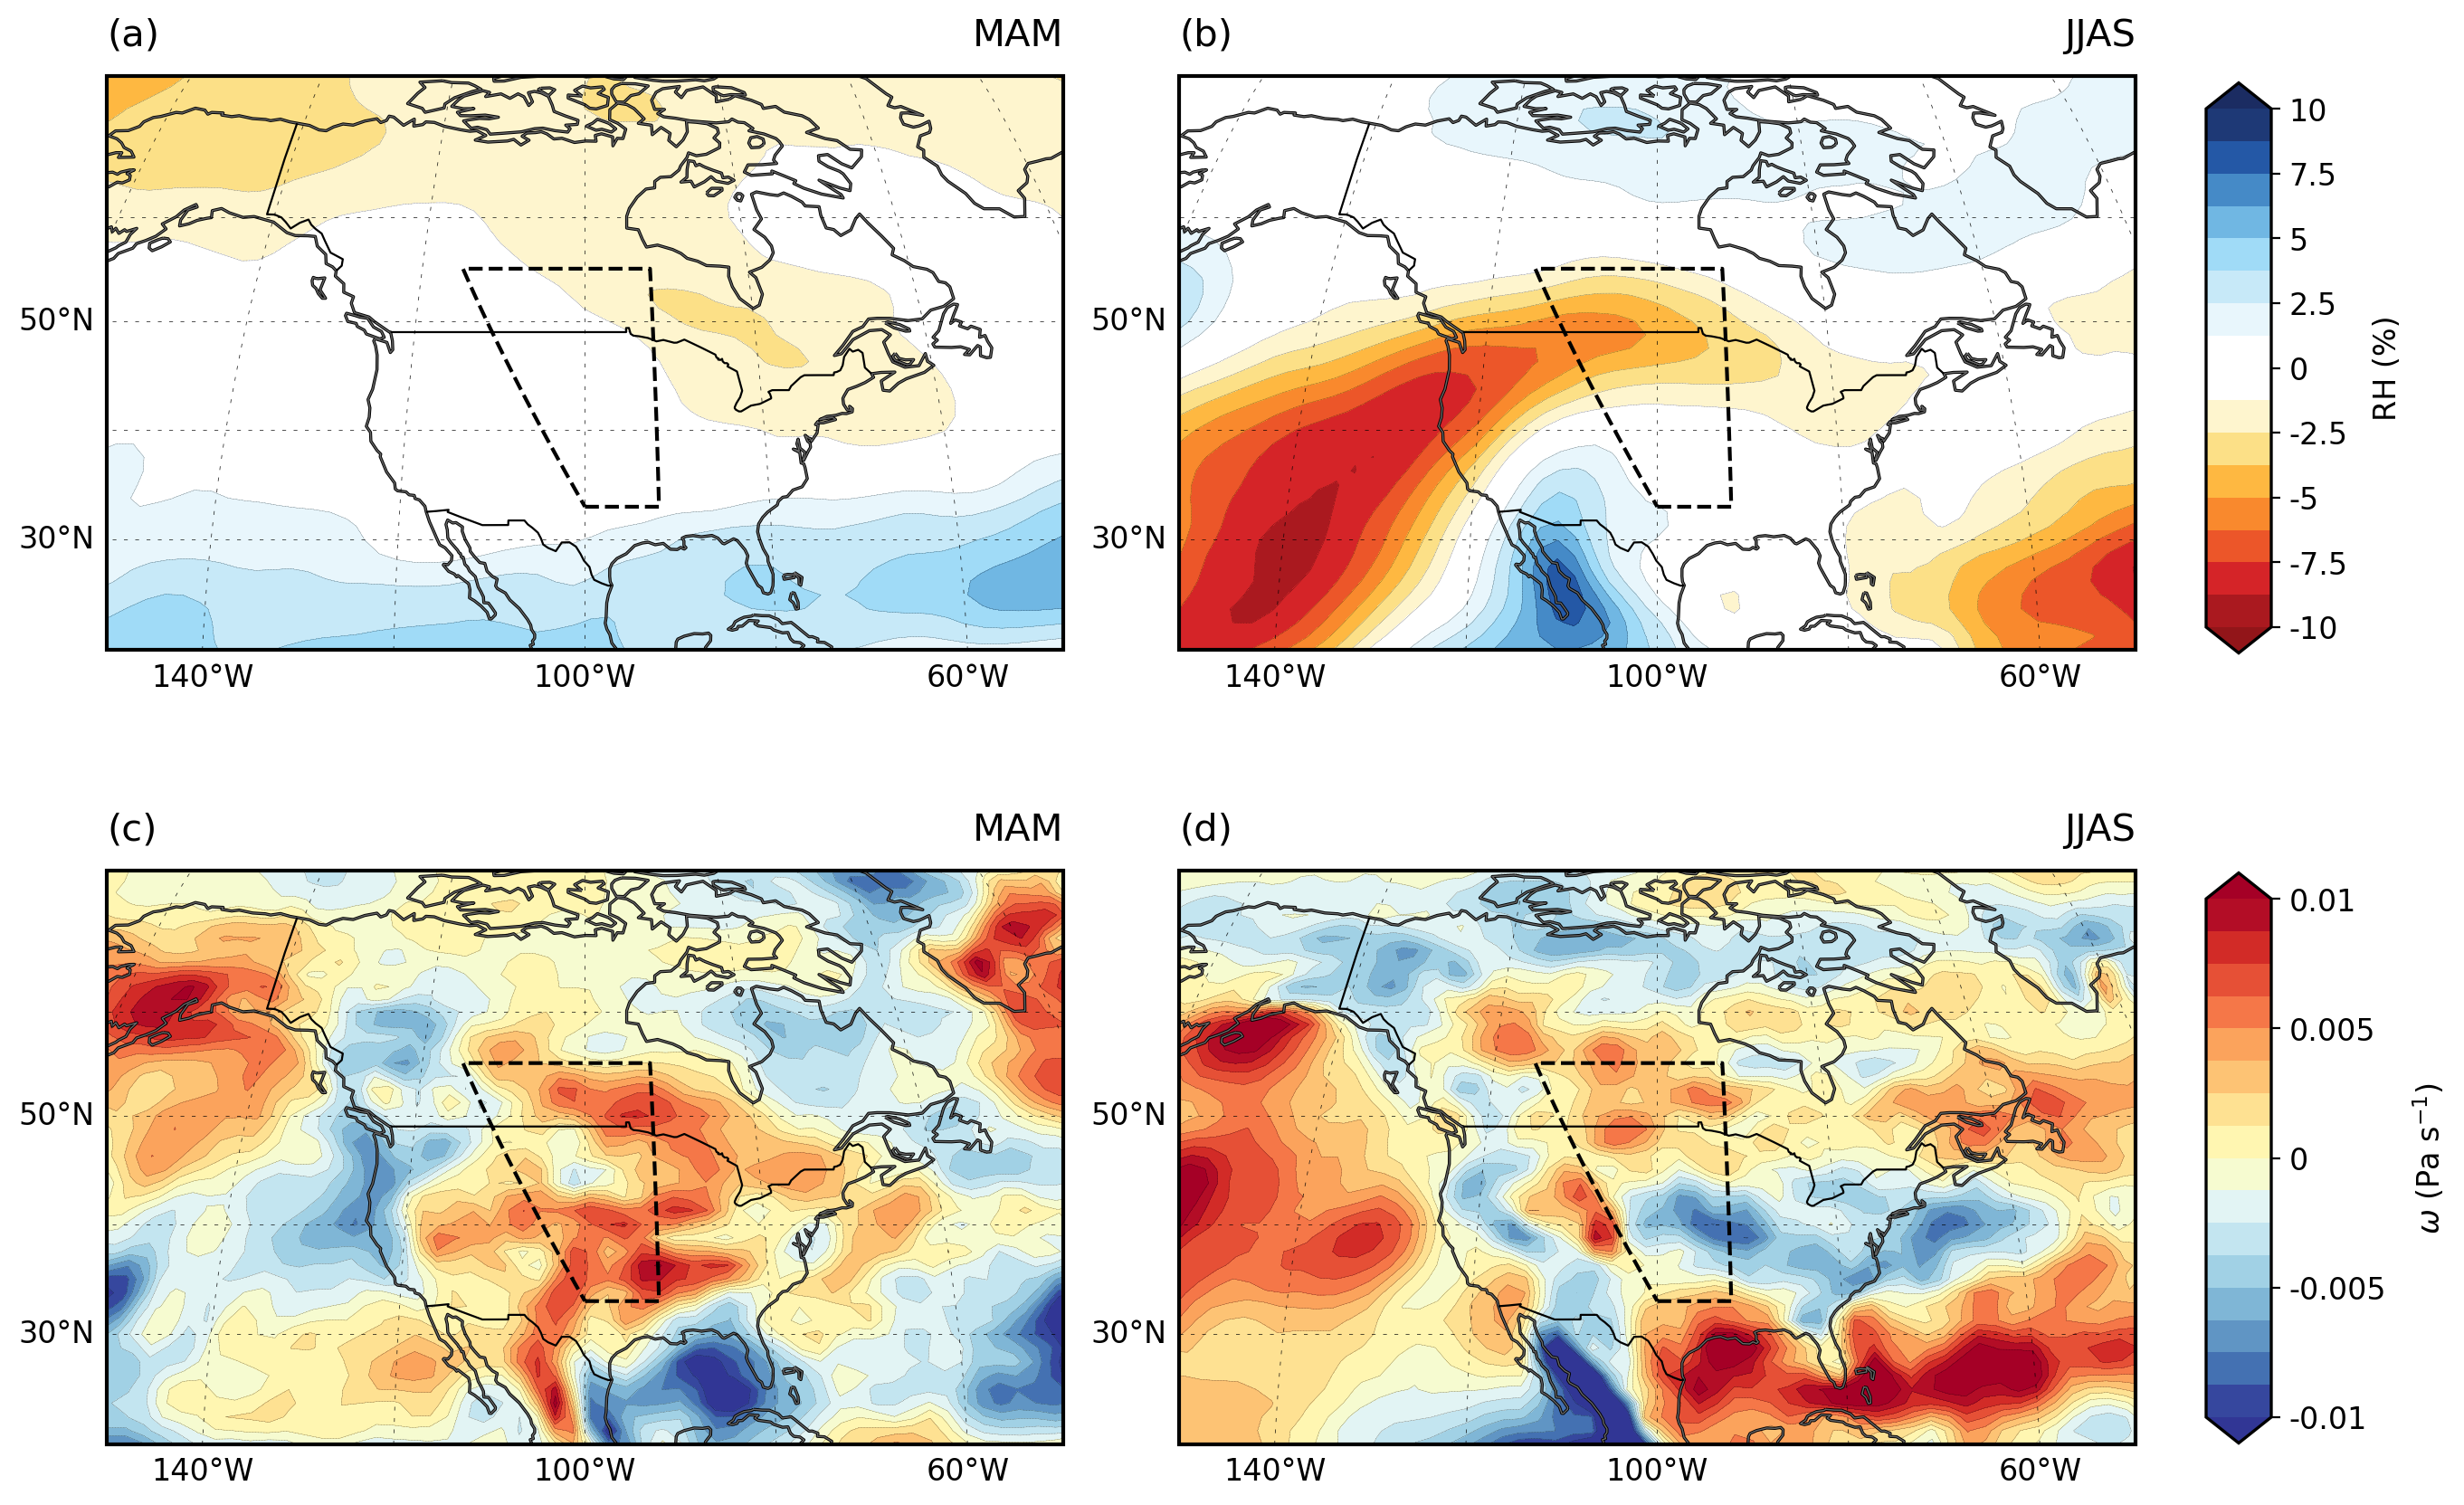

In [3]:
#------------------------------------------------------------
# Fig. S5: Relative Humidity and Omega anomalies
#------------------------------------------------------------

MH_means = um.importUMData(f"../Data/Models/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Models/Monthly_Means/PI_monthly_means_187001-194912.nc")

mh_rh = MH_means["rh_plev"].sel(p_levs=slice(300, 200)).mean(dim="p_levs")
pi_rh = PI_means["rh_plev"].sel(p_levs=slice(300, 200)).mean(dim="p_levs")

mh_om = MH_means["omega_plev"].sel(p_levs=500)
pi_om = PI_means["omega_plev"].sel(p_levs=500)

fig = plt.figure(figsize=(12, 9), dpi=200)
gs = gridspec.GridSpec(2, 2)
lims, proj = [-150, -50, 20, 75], ccrs.Robinson(central_longitude=-100)

GP_region = umplt.umRegion("GP")

plotData = [("MAM", [2, 3, 4]), ("JJAS", [5, 6, 7, 8])]
labels = np.array([["a", "b"], ["c", "d"]])

for i, (mh_var, pi_var) in enumerate(zip([mh_rh, mh_om], [pi_rh, pi_om])):
    if i == 0:
        cmap = get_cpt.get_cmap("BlueWhiteOrangeRed.cpt", reverse=True); v = 10; levs = np.linspace(-v, v, 17)
        cbar_lab = "RH (%)"; cbar_axes_loc = (1.02, 0.565, 0.03, 0.35)
        clevs = levs[~np.isclose(levs, 0.0)]
    elif i == 1:
        cmap = cm.RdYlBu_r; v = 1e-02; levs = np.linspace(-v, v, 17)
        cbar_lab = r"$\omega$ (Pa $\mathregular{s^{-1}})$"; cbar_axes_loc = (1.02, 0.08, 0.03, 0.35)
        clevs = levs

    for j, (period, mons) in enumerate(plotData):
        ax = plt.subplot(gs[i, j], projection=proj)
        umplt.plotBaseMap(ax, lims, coastlw=1.2, bordercol="black", borderlw=0.8, spinelw=1.5)
        umplt.plotGrid(ax,xlabeledlines=[-60, -100, -140],ylabeledlines=[30, 50],
                       xlines=[-40, -80, -120, -160], ylines=[20, 40, 60], labelsize=12, lw=0.3)
        

        anom = mh_var[mons].mean(dim="time") - pi_var[mons].mean(dim="time")
        LON, LAT = np.meshgrid(anom.lon_p, anom.lat_p)

        cf1 = ax.contourf(LON, LAT, anom, cmap=cmap, levels=levs, extend="both", transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
        c1 = ax.contour(LON, LAT, anom, extend="both", levels=clevs, colors="black", linestyles="dashed",
                        linewidths=0.1, transform=ccrs.PlateCarree(), transform_first=True, zorder=0)
        
        ax.set_title(period, loc="right", fontsize=15, pad=12)
        ax.set_title(f"({labels[i,j]})", loc="left", fontsize=15, pad=12)

        GP_region.plot(ax=ax, add_label=False, line_kws={"linestyle": "dashed", "color": "black", "linewidth": 1.5, "zorder": 0})

    cbaxes = fig.add_axes(cbar_axes_loc)
    cbar = plt.colorbar(cf1, orientation="vertical", cax=cbaxes)
    cbar.set_label(cbar_lab, size=12, labelpad=10)
    cbar.outline.set_linewidth(1.2)
    if i == 0:
        cbar.set_ticks(np.linspace(-v, v, 9), labels=["{:g}".format(x) for x in cbar.get_ticks()], fontsize=12)
    elif i == 1:
        cbar.set_ticks(np.linspace(-v, v, 5),labels=["{:g}".format(x) for x in np.linspace(-v, v, 5)], fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
#------------------------------------------------------------
# Calculate Pacific Jet Latitude for Fig. S6
#------------------------------------------------------------

mh_u = um.importUMData(f"../Data/Models/Timeseries/MH/u_wind_197001-204912.nc")
pi_u = um.importUMData(f"../Data/Models/Timeseries/PI/u_wind_187001-194912.nc")

mh_lats = []
pi_lats = []
for u_wind, out_lats in zip([mh_u, pi_u], [mh_lats, pi_lats]):
    u_wind = u_wind.coarsen(time=12).construct(time=["year", "month"]).isel(month=[5, 6, 7 ,8]).sel(air_pressure=200).mean(dim="month")
    u_wind_zonal = u_wind.sel({"longitude": slice(140, 230), "latitude": slice(10, 65)}).mean(dim="longitude")
    for i in range(u_wind_zonal.sizes["year"]):
        arr = u_wind_zonal.isel(year=i)
        out_lats.append(float(arr.latitude[arr.argmax(dim="latitude")].values))

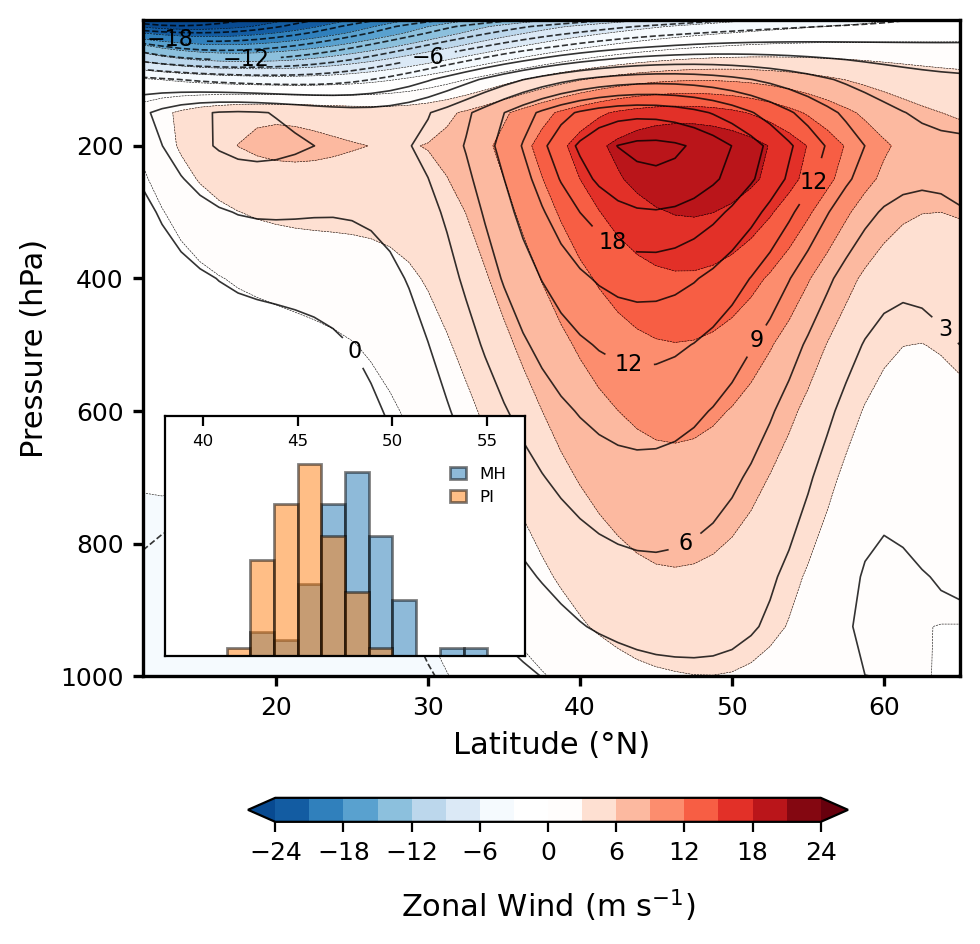

In [ ]:
#------------------------------------------------------------
# Fig. S6: Pacific Jet
#------------------------------------------------------------

MH_means = um.importUMData(f"../Data/Models/Monthly_Means/MH_monthly_means_197001-204912.nc")
PI_means = um.importUMData(f"../Data/Models/Monthly_Means/PI_monthly_means_187001-194912.nc")

LON, LAT = np.meshgrid(MH_means.lon_p, MH_means.lat_p)

mh_u = MH_means["u_wind"]
pi_u = PI_means["u_wind"]

pacific_region = [[140, 10], [230, 10], [230, 65], [140, 65]]
Pacific_Mask = umplt.umRegionMask(pacific_region, MH_means.lon_p, MH_means.lat_p, rgname="NPacific", rgabbrev="NPA")

mh_u_jaso = mh_u[[5, 6, 7, 8]].mean(dim="time").where(Pacific_Mask, drop=True)
pi_u_jaso = pi_u[[5, 6, 7, 8]].mean(dim="time").where(Pacific_Mask, drop=True)

max_mh = mh_u_jaso.where(mh_u_jaso == mh_u_jaso.max(), drop=True)
max_pi = pi_u_jaso.where(pi_u_jaso == pi_u_jaso.max(), drop=True)

colors = np.vstack((cm.Blues_r(np.linspace(0.1, 1, 8)), (1, 1, 1 ,1), (1, 1, 1, 1),cm.Reds(np.linspace(0.1, 1, 8))))
cmap = LinearSegmentedColormap.from_list("mycmap", colors)

v = 24; levs = np.linspace(-v, v, 17); 
cbar_lab = r"Zonal Wind (m $\mathregular{s^{-1}}$)"

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

p1 = ax.contourf(mh_u_jaso.lat_p, mh_u_jaso.p_levs, mh_u_jaso.mean(axis=2), extend="both", cmap=cmap, levels=levs)
p2 = ax.contour(mh_u_jaso.lat_p, mh_u_jaso.p_levs, mh_u_jaso.mean(axis=2), levels=levs, colors="black", linewidths=0.2, linestyles="dashed")
p3 = ax.contour(pi_u_jaso.lat_p, pi_u_jaso.p_levs, pi_u_jaso.mean(axis=2), levels=levs, colors="black", linewidths=0.6, alpha=0.8)

manual_locs = [(20, 700), (26, 500), (63, 500), (48, 850), (52, 500), (43, 550), (55, 250), (42, 350), (13, 40), (18, 70), (30, 70)]
p6 = ax.clabel(p3, manual=manual_locs, fontsize=8, inline_spacing=10)
for lbl in p6:
    lbl.set_rotation(0)
    lbl.set_alpha(1)

ax.invert_yaxis()
ax.set_xlabel("Latitude (°N)", fontsize=11) 
ax.set_ylabel("Pressure (hPa)", fontsize=11)
ax.tick_params("both", width=1.2, labelsize=9)

cbaxes = fig.add_axes((0.258, -0.04, 0.6, 0.03))
cbar = plt.colorbar(p1, orientation='horizontal', extend="both", ticks=np.linspace(-v, v, 9), cax=cbaxes)
cbar.ax.tick_params(labelsize=9) 
cbar.set_label(label=cbar_lab, size=11, labelpad=8)

for spine in ["top", "bottom", "left", "right"]:
    ax.spines[spine].set_linewidth(1.2)

axins = inset_axes(ax, width=1.8, height=1.2, loc="lower left", bbox_to_anchor=(0.01, 0.01),
                   bbox_transform=ax.transAxes)

bins = np.linspace(40, 55, 13)
axins.hist(mh_lats, bins=bins, alpha=0.5, edgecolor="k", label="MH")
axins.hist(pi_lats, bins=bins, alpha=0.5, edgecolor="k", label="PI")
axins.set_ylim(0, 30); axins.set_xlim(38, 57)

axins.tick_params(axis="both", labelsize=6)
axins.xaxis.set_label_position("top")
axins.xaxis.tick_top()
axins.tick_params(axis="x", direction="in", labeltop=True, labelbottom=False, pad=-12)

axins.tick_params(axis="y", left=False, right=False, labelleft=False, labelright=False)
axins.set_yticks([])
axins.yaxis.label.set_visible(False)
axins.legend(fontsize=6, handlelength=1, loc="upper right", bbox_to_anchor=(0.99, 0.85), frameon=False)

plt.tight_layout()
plt.show()